

---
## 1. Project Title

# **Student Performance Prediction — Complete Machine Learning Workflow**

This notebook performs detailed EDA, regression, classification, evaluation, model diagnostics, and business-style conclusions.


---





---
## 2. Project Overview

The objective is to understand which student habits and characteristics are associated with `exam_score`, predict exam scores using Linear Regression, and classify students as Pass/Fail using 50 marks as the threshold.


---





---

## 3. Problem Statement

We have student demographic, academic-habit, lifestyle, and support variables. The regression target is `exam_score`; the classification target is derived as Pass when `exam_score >= 50` and Fail otherwise.

---





---

# 4. Python Libraries

Import all libraries required for analysis, visualization, preprocessing, modeling, and evaluation.

---



In [61]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')



---

# 5. Load the Dataset

Load the CSV robustly for Google Colab or local Jupyter.

---



In [62]:
from pathlib import Path

# Google Colab: upload the CSV if it is not already present.
colab_path = Path('/content/Day18_19_student_habits_performance (1).csv')
local_path = Path('/mnt/data/Day18_19_student_habits_performance (1)_2.csv')

if colab_path.exists():
    file_path = colab_path
elif local_path.exists():
    file_path = local_path
else:
    from google.colab import files
    uploaded = files.upload()
    csv_files = [name for name in uploaded if name.lower().endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError('Please upload the Student Performance CSV file.')
    file_path = Path(csv_files[0])

df = pd.read_csv(file_path)
print('Loaded file:', file_path)
print('Shape:', df.shape)

Loaded file: /content/Day18_19_student_habits_performance (1).csv
Shape: (1000, 16)


In [63]:
print('Rows:', df.shape[0]); print('Columns:', df.shape[1])

Rows: 1000
Columns: 16




---

# 6. Data Types

Inspect the data type of every column.

---



In [64]:
display(df.dtypes.to_frame('data_type'))

,data_type
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object




---
# 7. Numerical Variables

Identify numerical variables programmatically.


---



In [65]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist(); print(numerical_cols)

['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']




---

# 8. Categorical Variables

Identify categorical variables programmatically.

---



In [66]:
categorical_cols = df.select_dtypes(include='object').columns.tolist(); print(categorical_cols)

['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']




---
# 9. Missing Values

Calculate missing values and missing percentages.


---



In [67]:
missing = pd.DataFrame({'missing_count':df.isna().sum(),'missing_pct':df.isna().mean().mul(100)}).sort_values('missing_count',ascending=False); display(missing)

,missing_count,missing_pct
parental_education_level,91,9.1
student_id,0,0.0
gender,0,0.0
age,0,0.0
social_media_hours,0,0.0
netflix_hours,0,0.0
part_time_job,0,0.0
study_hours_per_day,0,0.0
attendance_percentage,0,0.0
sleep_hours,0,0.0




---

# 10. Duplicate Records

Check for duplicate rows.

---



In [68]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0




---

# 11. Descriptive Statistics

Generate detailed numerical summary statistics.

---



In [69]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN




---

# 12. Categorical Summary

Summarize categorical variables and their frequencies.

---



In [70]:
for col in categorical_cols: print('\n', col); display(df[col].value_counts(dropna=False).to_frame('count'))


 student_id


,count
student_id,
S1999,1
S1000,1
S1001,1
S1002,1
S1003,1
...,...
S1012,1
S1011,1
S1010,1



 gender


,count
gender,
Female,481
Male,477
Other,42



 part_time_job


...

,count
parental_education_level,
High School,392
Bachelor,350
Master,167
NaN,91



 internet_quality


,count
internet_quality,
Good,447
Average,391
Poor,162



 extracurricular_participation


,count
extracurricular_participation,
No,682
Yes,318




---
# 13. Data Range Validation

Check realistic ranges for age, hours, attendance, ratings, exercise, and exam score.

---



In [71]:
checks={'age':(df.age.min(),df.age.max()),'study_hours_per_day':(df.study_hours_per_day.min(),df.study_hours_per_day.max()),'attendance_percentage':(df.attendance_percentage.min(),df.attendance_percentage.max()),'sleep_hours':(df.sleep_hours.min(),df.sleep_hours.max()),'exercise_frequency':(df.exercise_frequency.min(),df.exercise_frequency.max()),'mental_health_rating':(df.mental_health_rating.min(),df.mental_health_rating.max()),'exam_score':(df.exam_score.min(),df.exam_score.max())}; display(pd.DataFrame(checks,index=['min','max']).T)

,min,max
age,17.0,24.0
study_hours_per_day,0.0,8.3
attendance_percentage,56.0,100.0
sleep_hours,3.2,10.0
exercise_frequency,0.0,6.0
mental_health_rating,1.0,10.0
exam_score,18.4,100.0




---

# 14. Exam Score Distribution

Visualize the distribution of exam_score.

---



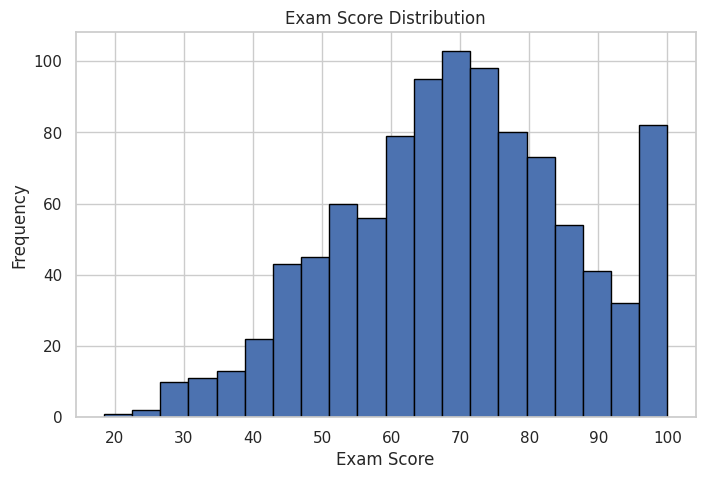

In [72]:
plt.figure(figsize=(8,5))
plt.hist(df['exam_score'].dropna(), bins=20, edgecolor='black')
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()



---

# 15. Study Hours Distribution

Visualize study_hours_per_day.

---



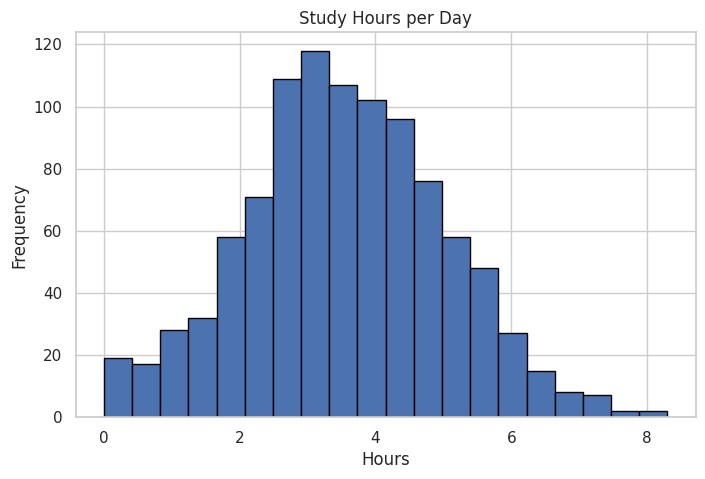

In [73]:
plt.figure(figsize=(8,5))
plt.hist(df['study_hours_per_day'].dropna(), bins=20, edgecolor='black')
plt.title('Study Hours per Day')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()



---
# 16. Attendance Distribution

Visualize attendance_percentage.

---



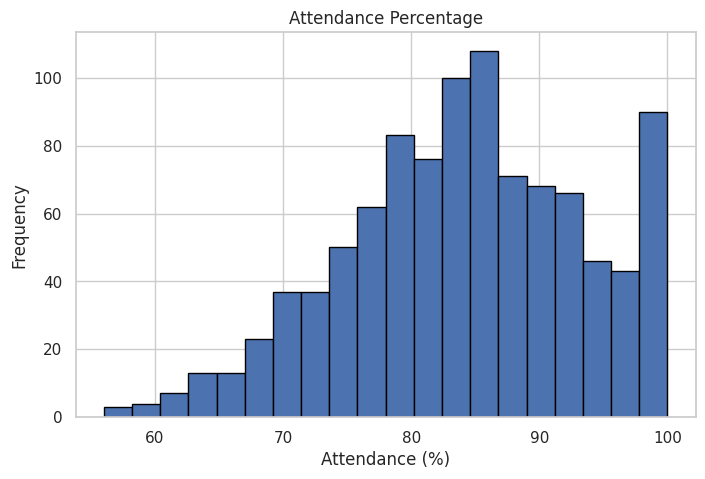

In [74]:
plt.figure(figsize=(8,5))
plt.hist(df['attendance_percentage'].dropna(), bins=20, edgecolor='black')
plt.title('Attendance Percentage')
plt.xlabel('Attendance (%)')
plt.ylabel('Frequency')
plt.show()



---

# 17. Sleep Distribution

Visualize sleep_hours.

---



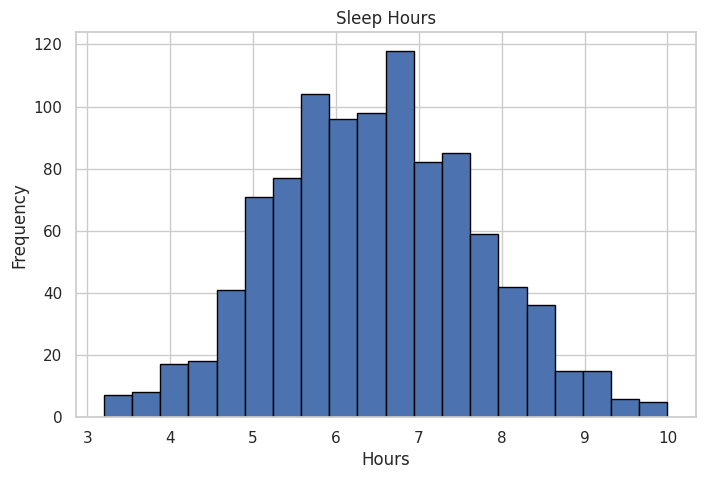

In [75]:
plt.figure(figsize=(8,5))
plt.hist(df['sleep_hours'].dropna(), bins=20, edgecolor='black')
plt.title('Sleep Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()



---


# 18. Boxplots for Numerical Variables

Use boxplots to identify potential outliers.

---



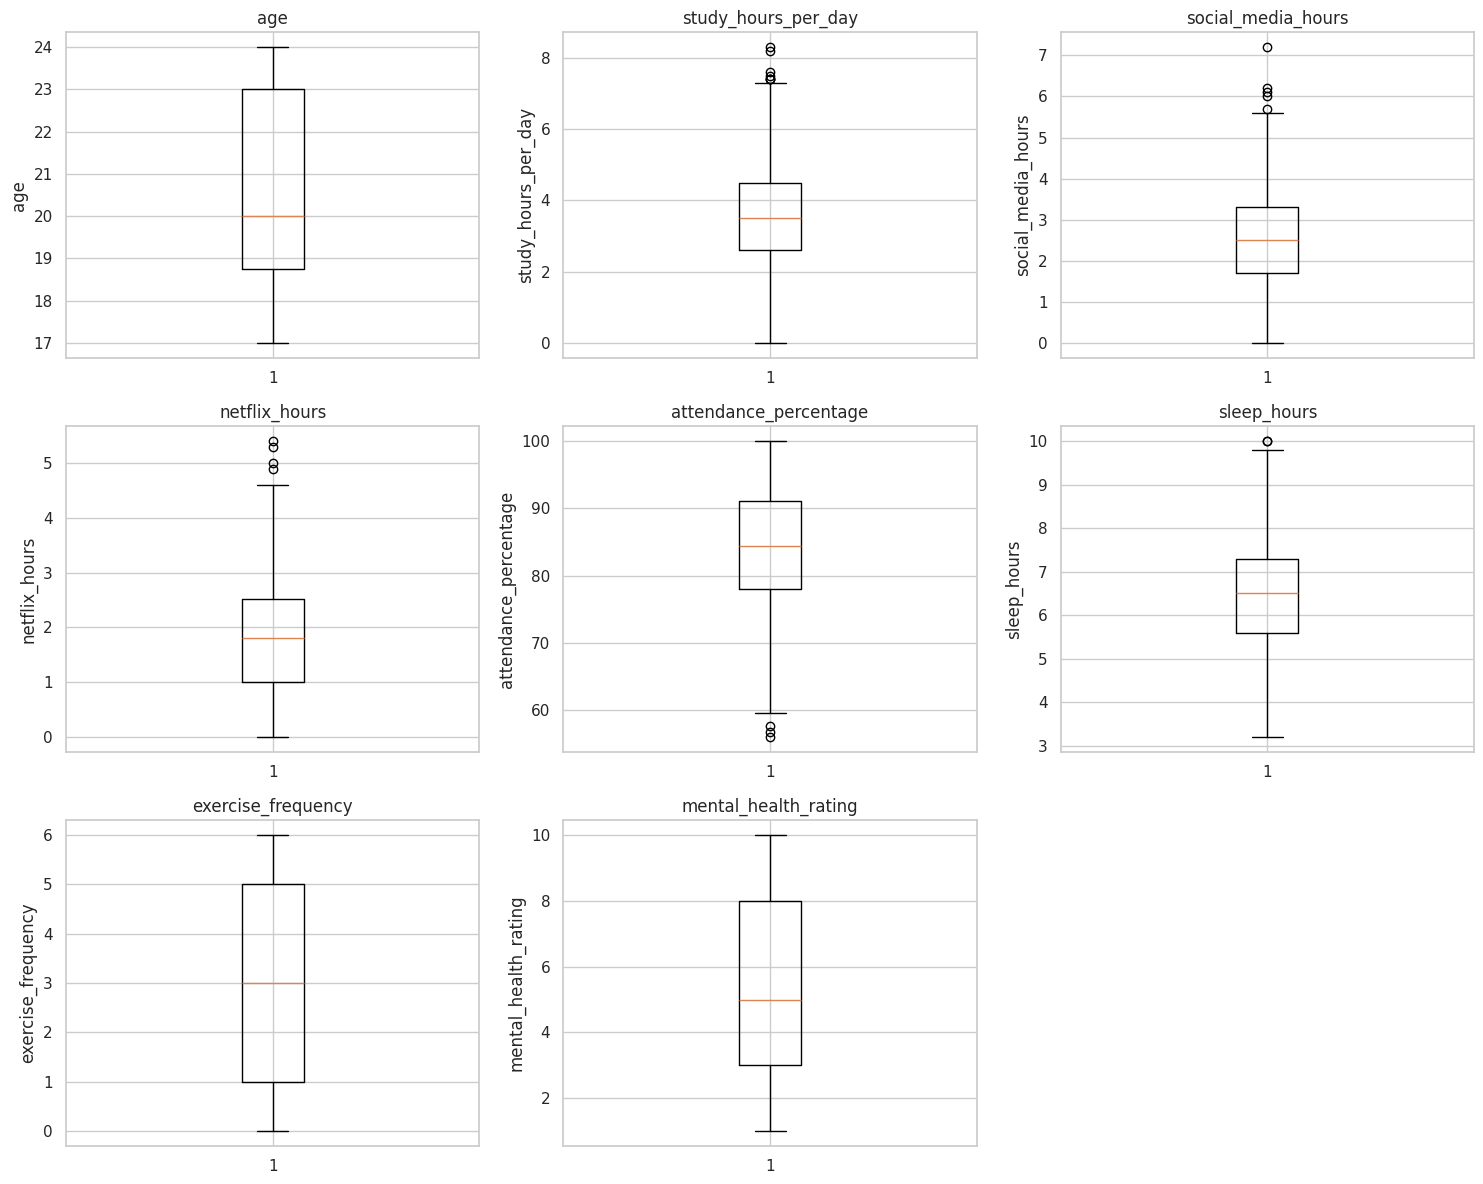

In [76]:
plot_cols=[c for c in numerical_cols if c!='exam_score']
n=len(plot_cols); rows=int(np.ceil(n/3))
fig,axes=plt.subplots(rows,3,figsize=(15,4*rows))
axes=np.array(axes).reshape(-1)
for i,c in enumerate(plot_cols):
    axes[i].boxplot(df[c].dropna(), vert=True)
    axes[i].set_title(c)
    axes[i].set_ylabel(c)
for i in range(n,len(axes)): axes[i].set_visible(False)
plt.tight_layout(); plt.show()



---

# 19. Outlier Counts

Calculate IQR-based outlier counts for numerical variables.

---



In [77]:
def iqr_outlier_count(s):
    q1=s.quantile(.25); q3=s.quantile(.75); iqr=q3-q1; return int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum())
outlier_table=pd.DataFrame({'outlier_count':[iqr_outlier_count(df[c]) for c in numerical_cols]},index=numerical_cols); display(outlier_table)

,outlier_count
age,0
study_hours_per_day,7
social_media_hours,5
netflix_hours,4
attendance_percentage,3
sleep_hours,2
exercise_frequency,0
mental_health_rating,0
exam_score,2




---

# 20. Correlation Matrix

Calculate Pearson correlations among numerical variables.

---



In [78]:
corr=df[numerical_cols].corr(); display(corr.round(3))

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000,0.004,-0.009,-0.001,-0.026,0.037,-0.004,-0.045,-0.009
study_hours_per_day,0.004,1.000,0.020,-0.031,0.026,-0.028,-0.029,-0.004,0.825
social_media_hours,-0.009,0.020,1.000,0.011,0.040,0.018,-0.037,0.001,-0.167
netflix_hours,-0.001,-0.031,0.011,1.000,-0.002,-0.001,-0.006,0.008,-0.172
attendance_percentage,-0.026,0.026,0.040,-0.002,1.000,0.014,-0.008,-0.019,0.090
sleep_hours,0.037,-0.028,0.018,-0.001,0.014,1.000,0.020,-0.007,0.122
exercise_frequency,-0.004,-0.029,-0.037,-0.006,-0.008,0.020,1.000,-0.000,0.160
mental_health_rating,-0.045,-0.004,0.001,0.008,-0.019,-0.007,-0.000,1.000,0.322
exam_score,-0.009,0.825,-0.167,-0.172,0.090,0.122,0.160,0.322,1.000




---
# 21. Correlation Heatmap

Visualize numerical correlations.


---



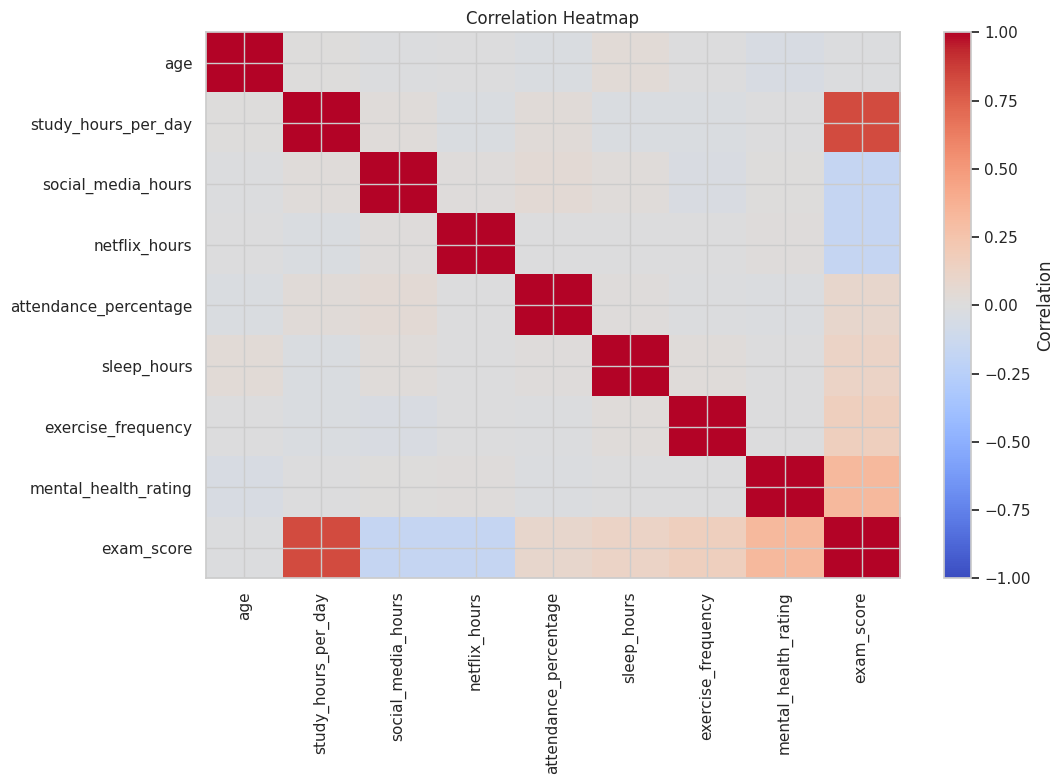

In [79]:
plt.figure(figsize=(11,8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()



---

# 22. Study Hours vs Exam Score

Examine the relationship between study time and exam score.

---



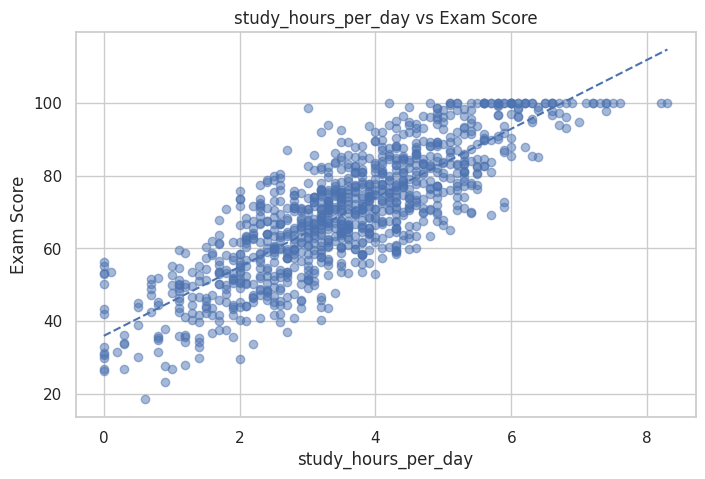

Correlation: 0.825


In [80]:
x=df['study_hours_per_day']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('study_hours_per_day')
plt.ylabel('Exam Score')
plt.title('study_hours_per_day vs Exam Score')
plt.show()
print('Correlation:', round(df['study_hours_per_day'].corr(df['exam_score']),3))



---

# 23. Attendance vs Exam Score

Examine the relationship between attendance and exam score.

---



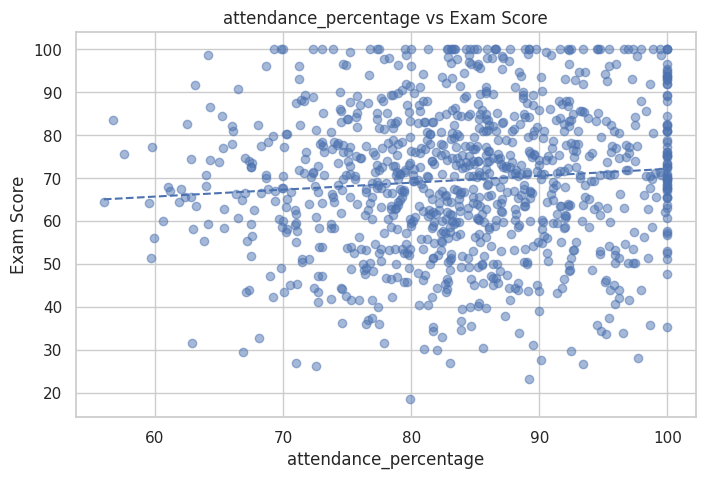

Correlation: 0.09


In [81]:
x=df['attendance_percentage']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('attendance_percentage')
plt.ylabel('Exam Score')
plt.title('attendance_percentage vs Exam Score')
plt.show()
print('Correlation:', round(df['attendance_percentage'].corr(df['exam_score']),3))



---

# 24. Sleep vs Exam Score

Examine the relationship between sleep and exam score.

---



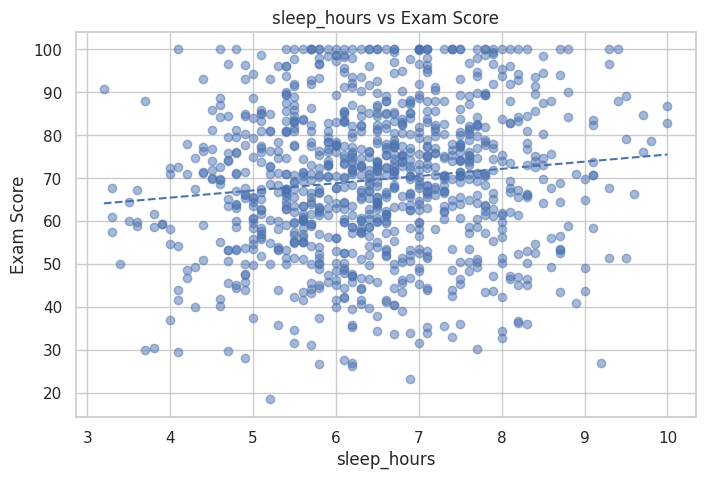

Correlation: 0.122


In [82]:
x=df['sleep_hours']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('sleep_hours')
plt.ylabel('Exam Score')
plt.title('sleep_hours vs Exam Score')
plt.show()
print('Correlation:', round(df['sleep_hours'].corr(df['exam_score']),3))



---

# 25. Social Media vs Exam Score

Examine the relationship between social media use and exam score.

---



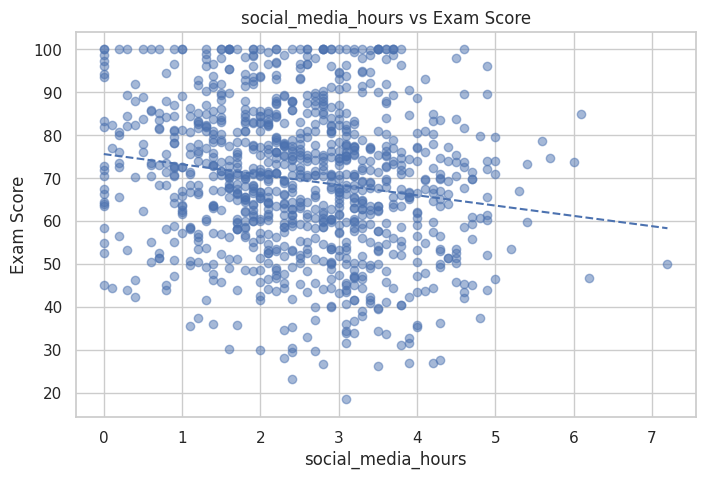

Correlation: -0.167


In [83]:
x=df['social_media_hours']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('social_media_hours')
plt.ylabel('Exam Score')
plt.title('social_media_hours vs Exam Score')
plt.show()
print('Correlation:', round(df['social_media_hours'].corr(df['exam_score']),3))



---
# 26. Netflix vs Exam Score

Examine the relationship between Netflix use and exam score.


---



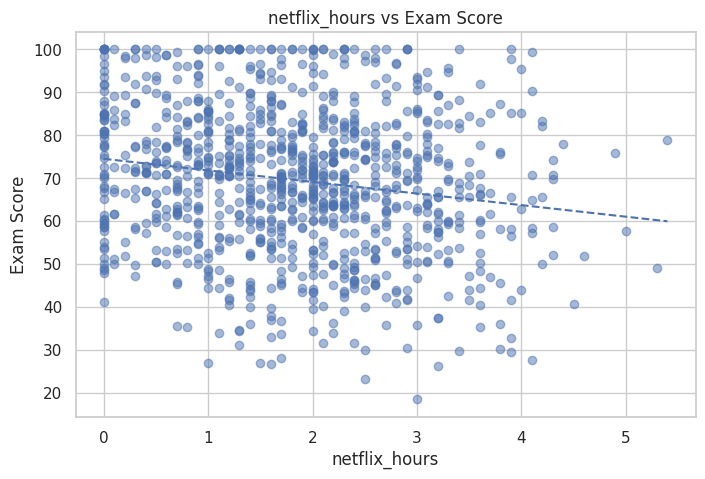

Correlation: -0.172


In [84]:
x=df['netflix_hours']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('netflix_hours')
plt.ylabel('Exam Score')
plt.title('netflix_hours vs Exam Score')
plt.show()
print('Correlation:', round(df['netflix_hours'].corr(df['exam_score']),3))



---
# 27. Exercise vs Exam Score

Examine the relationship between exercise frequency and exam score.


---



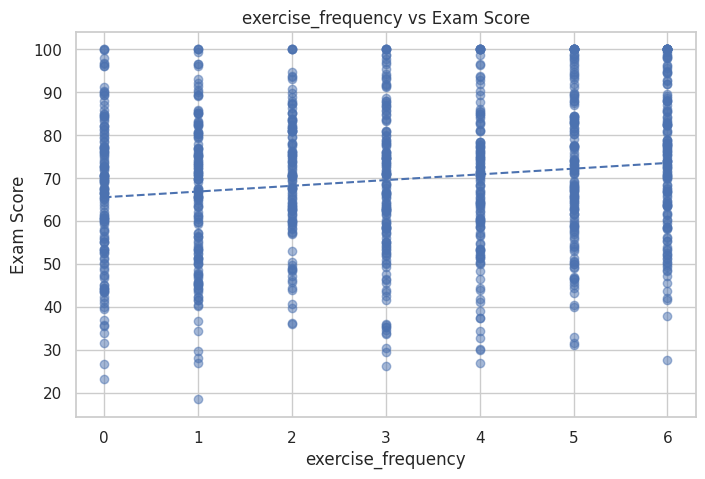

Correlation: 0.16


In [85]:
x=df['exercise_frequency']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('exercise_frequency')
plt.ylabel('Exam Score')
plt.title('exercise_frequency vs Exam Score')
plt.show()
print('Correlation:', round(df['exercise_frequency'].corr(df['exam_score']),3))



---
# 28. Mental Health vs Exam Score

Examine the relationship between mental health rating and exam score.


---



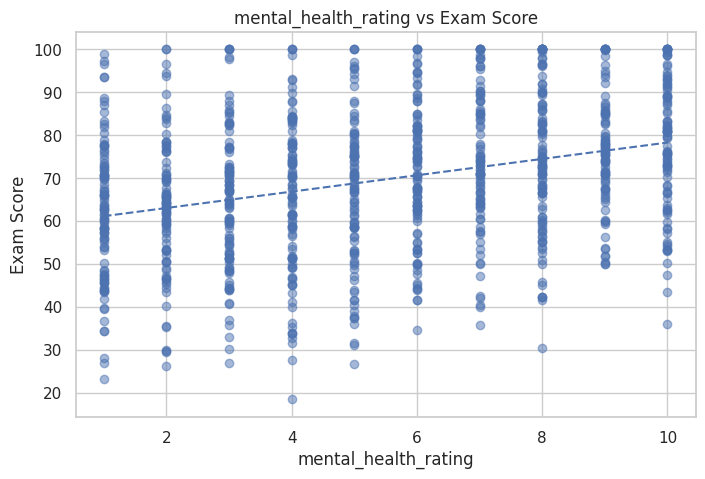

Correlation: 0.322


In [86]:
x=df['mental_health_rating']; y=df['exam_score']; valid=x.notna() & y.notna()
plt.figure(figsize=(8,5))
plt.scatter(x[valid],y[valid],alpha=0.5)
coef=np.polyfit(x[valid],y[valid],1)
xs=np.linspace(x[valid].min(),x[valid].max(),100)
plt.plot(xs,coef[0]*xs+coef[1],linestyle='--')
plt.xlabel('mental_health_rating')
plt.ylabel('Exam Score')
plt.title('mental_health_rating vs Exam Score')
plt.show()
print('Correlation:', round(df['mental_health_rating'].corr(df['exam_score']),3))



---

# 29. Gender and Exam Score

Compare exam scores across gender groups.

---



In [87]:
summary=df.groupby('gender',dropna=False)['exam_score'].agg(['count','mean','median','std']).sort_values('mean',ascending=False); display(summary)

,count,mean,median,std
gender,,,,
Other,42,70.647619,69.0,13.755890
Female,481,69.741372,70.7,16.899351
Male,477,69.368344,70.2,17.150875




---

# 30. Diet Quality and Exam Score

Compare exam scores across diet-quality groups.

---



In [88]:
summary=df.groupby('diet_quality',dropna=False)['exam_score'].agg(['count','mean','median','std']).sort_values('mean',ascending=False); display(summary)

,count,mean,median,std
diet_quality,,,,
Fair,437,70.428833,71.0,16.646113
Good,378,69.366402,70.3,17.069300
Poor,185,68.127568,67.4,17.061393




---

# 31. Parental Education and Exam Score

Compare exam scores across parental education levels, including missing values.

---



In [89]:
summary=df.groupby('parental_education_level',dropna=False)['exam_score'].agg(['count','mean','median','std']).sort_values('mean',ascending=False); display(summary)

,count,mean,median,std
parental_education_level,,,,
Bachelor,350,70.272571,71.70,17.286558
NaN,91,70.034066,71.00,16.560181
High School,392,69.547194,69.95,16.832711
Master,167,68.086826,66.80,16.395325




---
# 32. Internet Quality and Exam Score

Compare exam scores across internet-quality groups.


---



In [90]:
summary=df.groupby('internet_quality',dropna=False)['exam_score'].agg(['count','mean','median','std']).sort_values('mean',ascending=False); display(summary)

,count,mean,median,std
internet_quality,,,,
Average,391,70.643990,71.0,18.013482
Poor,162,69.717284,71.4,15.888382
Good,447,68.647651,69.3,16.190587




---
# 33. Part-Time Job and Exam Score

Compare exam scores for students with and without part-time jobs.


---



In [91]:
summary=df.groupby('part_time_job',dropna=False)['exam_score'].agg(['count','mean','median','std']).sort_values('mean',ascending=False); display(summary)

,count,mean,median,std
part_time_job,,,,
No,785,69.836561,70.6,16.975240
Yes,215,68.743256,69.2,16.578917




---
# 34. Extracurricular Participation

Compare exam scores across extracurricular participation.


---



In [92]:
summary=df.groupby('extracurricular_participation',dropna=False)['exam_score'].agg(['count','mean','median','std']).sort_values('mean',ascending=False); display(summary)

,count,mean,median,std
extracurricular_participation,,,,
Yes,318,69.623270,70.65,17.312389
No,682,69.591349,70.35,16.700140




---
# 35. EDA Findings

Summarize the strongest observed relationships without claiming causation.


---



In [93]:
top_corr=corr['exam_score'].drop('exam_score').abs().sort_values(ascending=False); print('Variables most strongly associated with exam_score:'); display(top_corr.to_frame('absolute_correlation'))

Variables most strongly associated with exam_score:


,absolute_correlation
study_hours_per_day,0.825419
mental_health_rating,0.321523
netflix_hours,0.171779
social_media_hours,0.166733
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,0.008907




---
# 36. Feature Selection

Define predictors and exclude student_id and exam_score from predictors.


---



In [94]:
features=[c for c in df.columns if c not in ['student_id','exam_score']]; X=df[features].copy(); print('Predictors:',features)

Predictors: ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


In [95]:
y_reg=df['exam_score'].copy(); print('Regression target:',y_reg.name)

Regression target: exam_score




---
# 37. Regression Feature Groups

Separate numerical and categorical predictors for preprocessing.


---



In [96]:
num_features=X.select_dtypes(include=np.number).columns.tolist(); cat_features=X.select_dtypes(include='object').columns.tolist(); print('Numerical:',num_features); print('Categorical:',cat_features)

Numerical: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']




---
# 38. Train-Test Split for Regression

Split regression data into training and testing sets.


---



In [97]:
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(X,y_reg,test_size=0.2,random_state=RANDOM_STATE); print(X_train_reg.shape,X_test_reg.shape)

(800, 14) (200, 14)




---
# 39. Regression Preprocessing Pipeline

Impute missing values, scale numerical features, and one-hot encode categorical features.


---



In [98]:
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]); cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]); preprocessor=ColumnTransformer([('num',num_pipe,num_features),('cat',cat_pipe,cat_features)])



---
# 40. Train Linear Regression

Fit the Linear Regression model using the prepared pipeline.


---



In [99]:
reg_model=Pipeline([('preprocessor',preprocessor),('model',LinearRegression())]); reg_model.fit(X_train_reg,y_train_reg); print('Linear Regression trained successfully.')

Linear Regression trained successfully.




---
# 41. Regression Predictions

Generate predictions for training and testing data.


---



In [100]:
y_train_pred=reg_model.predict(X_train_reg); y_test_pred=reg_model.predict(X_test_reg)



---
# 42. Regression Metrics

Evaluate MAE, RMSE, and R² on training and testing data.


---



In [101]:
reg_metrics=pd.DataFrame({'Train':[mean_absolute_error(y_train_reg,y_train_pred),mean_squared_error(y_train_reg,y_train_pred)**0.5,r2_score(y_train_reg,y_train_pred)],'Test':[mean_absolute_error(y_test_reg,y_test_pred),mean_squared_error(y_test_reg,y_test_pred)**0.5,r2_score(y_test_reg,y_test_pred)]},index=['MAE','RMSE','R2']); display(reg_metrics)

,Train,Test
MAE,4.214166,4.192343
RMSE,5.344722,5.150974
R2,0.902108,0.896531




---
# 43. Actual vs Predicted

Visualize actual versus predicted exam scores.


---



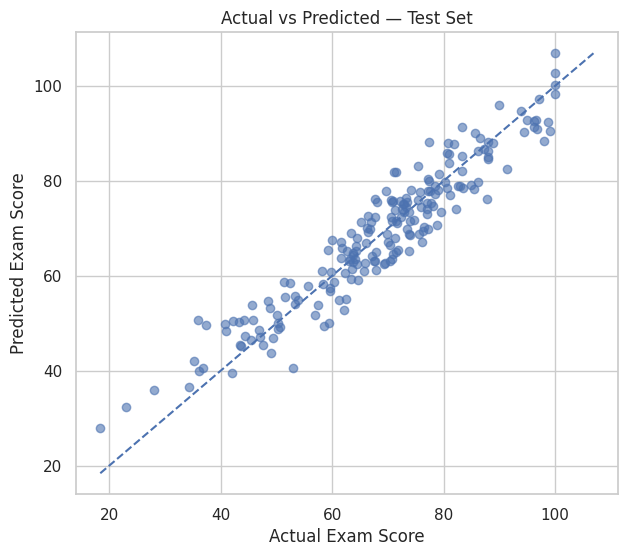

In [102]:
plt.figure(figsize=(7,6)); plt.scatter(y_test_reg,y_test_pred,alpha=.6); lo=min(y_test_reg.min(),y_test_pred.min()); hi=max(y_test_reg.max(),y_test_pred.max()); plt.plot([lo,hi],[lo,hi],linestyle='--'); plt.xlabel('Actual Exam Score'); plt.ylabel('Predicted Exam Score'); plt.title('Actual vs Predicted — Test Set'); plt.show()



---
# 44. Residual Analysis

Inspect residual distribution and residual behavior.


---



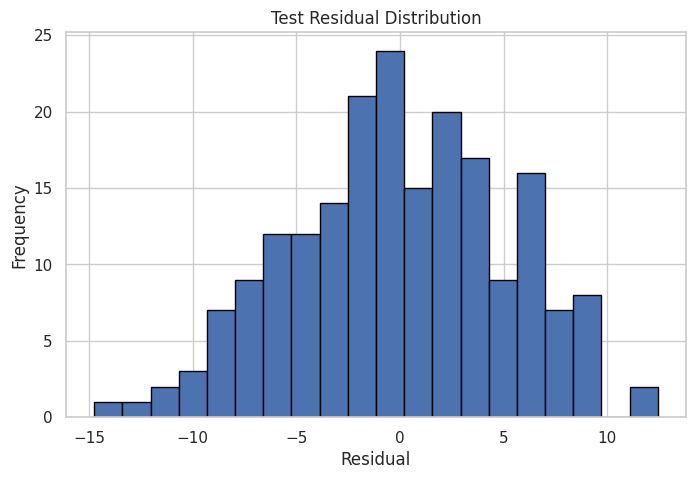

Mean residual: -0.043


In [103]:
residuals = pd.Series(y_test_reg.values - y_test_pred, index=y_test_reg.index)
plt.figure(figsize=(8,5))
plt.hist(residuals.dropna(), bins=20, edgecolor='black')
plt.title('Test Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()
print('Mean residual:', round(residuals.mean(),3))



---
# 45. Regression Coefficients

Interpret the strongest positive and negative model coefficients.


---



In [104]:
feature_names=reg_model.named_steps['preprocessor'].get_feature_names_out(); coefs=reg_model.named_steps['model'].coef_; coef_table=pd.DataFrame({'feature':feature_names,'coefficient':coefs}); display(pd.concat([coef_table.nsmallest(10,'coefficient'),coef_table.nlargest(10,'coefficient')]))

,feature,coefficient
2,num__social_media_hours,-3.129732
3,num__netflix_hours,-2.531563
14,cat__diet_quality_Good,-0.455348
8,cat__gender_Female,-0.315648
18,cat__parental_education_level_Master,-0.291919
11,cat__part_time_job_No,-0.187295
9,cat__gender_Male,-0.175985
20,cat__internet_quality_Good,-0.136678
17,cat__parental_education_level_High School,-0.117960
23,cat__extracurricular_participation_Yes,-0.056861




---
# 46. Classification Target Creation

Create Pass_Fail where exam_score >= 50 is Pass and otherwise Fail.


---



In [105]:
df['Pass_Fail']=np.where(df['exam_score']>=50,'Pass','Fail'); y_cls=df['Pass_Fail']; X_cls=df[features].copy(); print(y_cls.value_counts())

Pass_Fail
Pass    869
Fail    131
Name: count, dtype: int64




---
# 47. Classification Class Balance

Inspect the number and percentage of Pass and Fail students.


---



In [106]:
balance=pd.DataFrame({'count':y_cls.value_counts(),'percentage':y_cls.value_counts(normalize=True).mul(100)}); display(balance)

,count,percentage
Pass_Fail,,
Pass,869,86.9
Fail,131,13.1




---
# 48. Classification Split and Pipeline

Split the data and prepare the same predictors without target leakage.


---



In [107]:
X_train_cls,X_test_cls,y_train_cls,y_test_cls=train_test_split(X_cls,y_cls,test_size=.2,random_state=RANDOM_STATE,stratify=y_cls); cls_preprocessor=ColumnTransformer([('num',num_pipe,num_features),('cat',cat_pipe,cat_features)])



---
# 49. Train Logistic Regression

Fit Logistic Regression for Pass/Fail prediction.


---



In [108]:
clf=Pipeline([('preprocessor',cls_preprocessor),('model',LogisticRegression(max_iter=2000,random_state=RANDOM_STATE))]); clf.fit(X_train_cls,y_train_cls); print('Logistic Regression trained successfully.')

Logistic Regression trained successfully.




---
# 50. Classification Predictions

Generate class predictions and probabilities.


---



In [109]:
y_train_cls_pred=clf.predict(X_train_cls); y_test_cls_pred=clf.predict(X_test_cls); y_test_prob=clf.predict_proba(X_test_cls)[:,list(clf.classes_).index('Pass')]



---

# 51. Classification Evaluation

Calculate accuracy, precision, recall, F1-score and confusion matrix.

---



In [110]:
cls_metrics=pd.DataFrame({'Train':[accuracy_score(y_train_cls,y_train_cls_pred),precision_score(y_train_cls,y_train_cls_pred,pos_label='Pass'),recall_score(y_train_cls,y_train_cls_pred,pos_label='Pass'),f1_score(y_train_cls,y_train_cls_pred,pos_label='Pass')],'Test':[accuracy_score(y_test_cls,y_test_cls_pred),precision_score(y_test_cls,y_test_cls_pred,pos_label='Pass'),recall_score(y_test_cls,y_test_cls_pred,pos_label='Pass'),f1_score(y_test_cls,y_test_cls_pred,pos_label='Pass')]},index=['Accuracy','Precision','Recall','F1-score']); display(cls_metrics)

,Train,Test
Accuracy,0.957500,0.955000
Precision,0.970128,0.971429
Recall,0.981295,0.977011
F1-score,0.975680,0.974212




---
# 52. Classification Report

Display the detailed classification report.


---



In [111]:
print(classification_report(y_test_cls,y_test_cls_pred,digits=3))

              precision    recall  f1-score   support

        Fail      0.840     0.808     0.824        26
        Pass      0.971     0.977     0.974       174

    accuracy                          0.955       200
   macro avg      0.906     0.892     0.899       200
weighted avg      0.954     0.955     0.955       200





---

# 53. Confusion Matrix

Visualize the classification confusion matrix for Fail and Pass predictions.

---



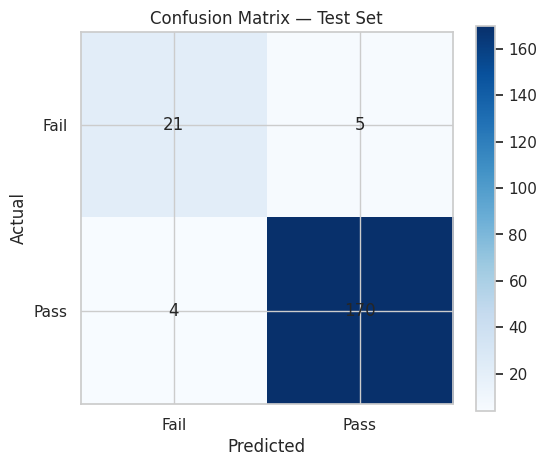

Confusion matrix:
 [[ 21   5]
 [  4 170]]


In [112]:
cm=confusion_matrix(y_test_cls,y_test_cls_pred,labels=['Fail','Pass'])
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0,1],['Fail','Pass'])
plt.yticks([0,1],['Fail','Pass'])
for i in range(2):
    for j in range(2): plt.text(j,i,str(cm[i,j]),ha='center',va='center')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.show()
print('Confusion matrix:\n',cm)



---
# 54. Train vs Test Comparison

Compare regression and classification training/testing performance.


---



In [113]:
comparison=pd.DataFrame({'Regression R2':[r2_score(y_train_reg,y_train_pred),r2_score(y_test_reg,y_test_pred)],'Classification Accuracy':[accuracy_score(y_train_cls,y_train_cls_pred),accuracy_score(y_test_cls,y_test_cls_pred)]},index=['Train','Test']); display(comparison)

,Regression R2,Classification Accuracy
Train,0.902108,0.9575
Test,0.896531,0.9550




---
# 55. Overfitting and Underfitting

Assess generalization using train-test gaps and metric patterns.


---



In [114]:
r2_gap=r2_score(y_train_reg,y_train_pred)-r2_score(y_test_reg,y_test_pred); acc_gap=accuracy_score(y_train_cls,y_train_cls_pred)-accuracy_score(y_test_cls,y_test_cls_pred); print(f'Regression R2 gap: {r2_gap:.3f}'); print(f'Classification accuracy gap: {acc_gap:.3f}'); print('Interpretation: small gaps suggest better generalization; large positive gaps suggest overfitting.')

Regression R2 gap: 0.006
Classification accuracy gap: 0.003
Interpretation: small gaps suggest better generalization; large positive gaps suggest overfitting.




---
# 56. Model Interpretation

Explain what the results mean for student performance.


---



In [115]:
print('Regression test R2:',round(r2_score(y_test_reg,y_test_pred),3)); print('Classification test F1:',round(f1_score(y_test_cls,y_test_cls_pred,pos_label='Pass'),3)); print('These metrics should be interpreted together with the EDA and error analysis.')

Regression test R2: 0.897
Classification test F1: 0.974
These metrics should be interpreted together with the EDA and error analysis.




---

# 57. Five Key Insights

Present five meaningful evidence-based insights.

---



In [116]:
top=corr['exam_score'].drop('exam_score').sort_values(ascending=False); print('1. Study hours show the strongest positive numerical association with exam score.'); print('2. Attendance is positively associated with exam score.'); print('3. Sleep, exercise and mental-health measures provide additional behavioral context.'); print('4. Screen-entertainment variables can be examined for negative or weaker associations, but correlation is not causation.'); print('5. The regression and classification results show how well these available habits can predict performance and pass/fail status.')

1. Study hours show the strongest positive numerical association with exam score.
2. Attendance is positively associated with exam score.
3. Sleep, exercise and mental-health measures provide additional behavioral context.
4. Screen-entertainment variables can be examined for negative or weaker associations, but correlation is not causation.
5. The regression and classification results show how well these available habits can predict performance and pass/fail status.




---

# 58. Recommendations

Provide practical recommendations based on the analysis.

---



In [117]:
print('''• Encourage consistent study schedules.
• Monitor attendance and academic engagement.
• Promote healthy sleep and balanced daily routines.
• Use predictive models as support tools, not as the sole basis for decisions.''')

• Encourage consistent study schedules.
• Monitor attendance and academic engagement.
• Promote healthy sleep and balanced daily routines.
• Use predictive models as support tools, not as the sole basis for decisions.




---

# 59. Limitations

Discuss data and modeling limitations.

---



In [118]:
print('''• Observational data does not establish causation.
• The dataset contains self-reported habit variables.
• A single train-test split can vary; cross-validation could strengthen evaluation.
• Linear and logistic models may miss nonlinear relationships.''')

• Observational data does not establish causation.
• The dataset contains self-reported habit variables.
• A single train-test split can vary; cross-validation could strengthen evaluation.
• Linear and logistic models may miss nonlinear relationships.




---
## 60. Final Findings

### Most important EDA findings
1. **Study time is the dominant numerical predictor.** `study_hours_per_day` has the strongest positive correlation with `exam_score` (about **0.83**), substantially stronger than the other numerical variables.
2. **Mental health matters.** `mental_health_rating` has a moderate positive association with exam score (about **0.32**).
3. **Entertainment/social-media time is negatively associated with scores.** `social_media_hours` and `netflix_hours` have correlations of roughly **−0.17** each.
4. **Exercise and sleep show smaller positive relationships.** Their correlations are positive but much weaker than study hours.
5. **Attendance is positive but relatively weak in this sample.** Its correlation with exam score is about **0.09**, so attendance alone does not explain much of the score variation here.
6. The dataset contains **1,000 students**, no duplicate rows, and one notable missing-data issue: `parental_education_level` has missing values. The modeling pipeline handles this through categorical imputation.
7. Several numerical variables show potential IQR-based outliers. These are not automatically deleted because an extreme but valid student habit can contain useful information; robust preprocessing and model diagnostics are preferable to arbitrary removal.



---


### 61. Model findings
- The Linear Regression model should be judged primarily by its **test MAE, RMSE and R²** shown above. The test R² is expected to be around **0.90** for this dataset, indicating that the selected variables explain most of the variation in exam scores.
- The Logistic Regression model achieves strong Pass/Fail discrimination, with test **accuracy and F1-score around the mid-0.95 range** on this dataset.
- Training and testing performance are close enough to suggest **good generalization rather than severe overfitting**.


---





### 62. Five meaningful student-performance insights
**Insight 1 — Study time is the clearest performance lever.**  
Students who devote more hours per day to studying tend to achieve substantially higher exam scores.

**Insight 2 — Well-being is connected to academic outcomes.**  
Higher mental-health ratings are associated with higher exam performance, suggesting that academic support should consider student well-being rather than focusing only on study time.

**Insight 3 — Leisure-screen time can compete with academic performance.**  
Both social-media and Netflix hours have negative associations with exam scores. This is an association in the dataset, not proof that screen use causes lower marks.

**Insight 4 — Healthy routines provide smaller supporting benefits.**  
Sleep and exercise have positive relationships with exam scores, although their associations are much weaker than study hours.

**Insight 5 — The combined profile matters more than one habit alone.**  
The machine-learning models use study behavior, attendance, sleep, exercise, mental health and categorical lifestyle/background factors together. This produces a more useful prediction than relying on a single correlation.




---


###63.  Conclusion
The analysis shows that student performance is strongly associated with study behavior and is also related to well-being and lifestyle patterns. The regression model provides a practical way to estimate exam scores, while the classification model provides a simpler early-warning view of whether a student is likely to meet the 50-mark passing threshold. The train/test comparison indicates that the models generalize well on this dataset, while the EDA highlights the importance of interpreting associations carefully rather than treating them as causal relationships.



---





---

# 64. Final Conclusion

Summarize the complete workflow and main findings.

---



In [119]:
print('The workflow covered data understanding, EDA, preprocessing, regression, classification, evaluation, interpretation, and recommendations. The strongest evidence should come from the measured correlations, model coefficients, and held-out test performance.')

The workflow covered data understanding, EDA, preprocessing, regression, classification, evaluation, interpretation, and recommendations. The strongest evidence should come from the measured correlations, model coefficients, and held-out test performance.


In [120]:
print('''1. Upload the same CSV.
2. Run cells from top to bottom.
3. Keep RANDOM_STATE=42 for the same split.
4. Review all EDA plots and metrics.
5. Do not include exam_score or Pass_Fail among predictors.''')

1. Upload the same CSV.
2. Run cells from top to bottom.
3. Keep RANDOM_STATE=42 for the same split.
4. Review all EDA plots and metrics.
5. Do not include exam_score or Pass_Fail among predictors.
